**Cell 1**

# 03 Signal search

1. 3,240 regressions: 30 spreads × 36 drivers × 3 horizons.
2. Fair value for 8 spreads, re-fitted each week.
3. Trading rule with costs.

Rules: drivers from `_KNOWN` columns; entry at next week's mean price; scoring on held-out weeks.

In [1]:
# Cell 2
import os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from cycler import cycler
import statsmodels.api as sm
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 200)

**Cell 3**

**Goal.** Load the libraries this notebook uses.

**Method.** pandas and numpy for the panel, matplotlib and cycler for the charts, statsmodels for the regressions and the Newey-West standard errors, `time` for the two run clocks in Cell 14 and Cell 35.

**Outcome.** The libraries load.

**Interpretation.** Every later cell depends on this one.

In [2]:
# Cell 4
# chart style
SURFACE, INK, INK_2, MUTED, GRID, AXIS = '#fcfcfb', '#0b0b0b', '#52514e', '#898781', '#e1e0d9', '#c3c2b7'
BLUE, ORANGE, AQUA, YELLOW = '#2a78d6', '#eb6834', '#1baf7a', '#eda100'
plt.rcParams.update({
    'figure.facecolor': SURFACE, 'axes.facecolor': SURFACE, 'savefig.facecolor': SURFACE,
    'axes.edgecolor': AXIS, 'axes.labelcolor': INK_2, 'xtick.color': MUTED, 'ytick.color': MUTED, 'text.color': INK,
    'axes.grid': True, 'grid.color': GRID, 'grid.linewidth': 0.8, 'grid.linestyle': '-',
    'axes.spines.top': False, 'axes.spines.right': False, 'axes.titlelocation': 'left', 'axes.titlesize': 12,
    'axes.titleweight': 'semibold', 'lines.linewidth': 2, 'legend.frameon': False, 'figure.figsize': (10, 4),
    'font.family': 'sans-serif', 'font.sans-serif': ['Segoe UI', 'Arial', 'DejaVu Sans'],
    'axes.prop_cycle': cycler(color=[BLUE, ORANGE, AQUA, YELLOW]),
})

**Cell 5**

**Goal.** Fix one chart style for every figure in the notebook.

**Method.** Set matplotlib defaults: an off-white ground, four colours, left-aligned titles, and the top and right spines hidden.

**Outcome.** Every later figure takes these settings.

**Interpretation.** The figures this notebook saves to `figures/` are the ones the README and the dashboard publish, so the style is set once here.

In [3]:
# Cell 6
PANEL_FILE = '../data/weekly_panel.csv'
SCORE_FILE = '../results/price_eda_scorecard.csv'
TRAIN = ('2015-01-09', '2018-12-28')     # train
TEST = ('2019-01-04', '2020-02-28')      # test
WF_START = '2017-01-06'                   # walk-forward start
WF_END = '2020-05-22'                     # walk-forward end
PRE_COVID_END = pd.Timestamp('2020-02-28')
HORIZONS = [1, 2, 4]                      # weeks
COST = 0.25                               # c/gal per unit traded
FDR_Q = 0.10                              # FDR level
SHORTLIST = ['LA_GC_1', 'LA_JET_M2M3', 'SING_GC_1', 'HO_BRENT']
os.makedirs('../figures', exist_ok=True)
os.makedirs('../results', exist_ok=True)

**Cell 7**

**Goal.** Fix the samples, the horizons, the cost and the shortlist before any test runs.

**Method.** Training 2015-01-09 to 2018-12-28, test 2019-01-04 to 2020-02-28. The walk-forward runs 2017-01-06 to 2020-05-22. Horizons 1, 2 and 4 weeks. Cost 0.25 c/gal per unit traded. False discovery rate 0.10. The shortlist is the four spreads notebook 01 selected.

**Outcome.** Nine settings, and the `figures` and `results` folders created.

**Interpretation.** Training and test split at the end of 2018, so every result in section 2 is scored on weeks outside its fit sample. The walk-forward starts in 2017 because a fair-value fit needs two years of history before its first forecast.

**Cell 8**

## 1. Spreads and drivers

In [4]:
# Cell 9
PANEL = pd.read_csv(PANEL_FILE, index_col=0, parse_dates=True)
SCORE = pd.read_csv(SCORE_FILE, index_col=0)
TARGETS = SCORE.index[(SCORE['group'] != 'flat') & (~SCORE['rebuilt'])].tolist()   # 30 candidates
print(len(TARGETS), 'spreads:', TARGETS)

30 spreads: ['LA_GC_1', 'NY_GC_1', 'NWE_GC_1', 'SING_GC_1', 'LA_JET_M1M2', 'LA_JET_M2M3', 'GC_JET_M1M2', 'GC_JET_M2M3', 'NY_JET_M1M2', 'NY_JET_M2M3', 'HO_M1M2', 'HO_M2M3', 'WTI_M1M2', 'WTI_M2M3', 'BRENT_M1M2', 'BRENT_M2M3', 'GASOIL_M1M2', 'GASOIL_M2M3', 'NWE_JET_M1M2', 'NWE_JET_M2M3', 'SING_KERO_M1M2', 'SING_KERO_M2M3', 'LA_DIFF_1', 'GC_DIFF_1', 'NY_DIFF_1', 'GC_JET_BRENT', 'HO_BRENT', 'BRENT_WTI', 'HO_GASOIL', 'NWE_JET_GASOIL']


**Cell 10**

**Goal.** Take the candidate spreads from notebook 01.

**Method.** Read the notebook 01 scorecard and keep every series that is a spread and survived the rebuilt-identity check.

**Outcome.** 30 spreads: four regional, twelve jet and product time spreads, four crude time spreads, three diffs, and the cracks and inter-product spreads.

**Interpretation.** These 30 are the whole candidate set, fixed before the first test, so the count of tests in Cell 16 is known in advance and the false-discovery correction can use it.

In [5]:
# Cell 11
# drivers from _KNOWN columns
X = pd.DataFrame(index=PANEL.index)
LEVELS = ['P1_JET_STOCKS_VS_5Y', 'P3_JET_STOCKS_VS_5Y', 'P5_JET_STOCKS_VS_5Y', 'US_JET_STOCKS_VS_5Y', 'P5_DAYS_SUPPLY', 'US_DAYS_SUPPLY',
          'P5_RUNS_VS_5Y', 'P3_RUNS_VS_5Y', 'US_UTIL_VS_5Y', 'P5_OUTPUT_VS_52W', 'P3_OUTPUT_VS_52W', 'P5_IMPORTS_4W',
          'US_DIST_STOCKS_VS_5Y', 'P1_DIST_STOCKS_VS_5Y']
for c in LEVELS:
    X[c] = PANEL[c + '_KNOWN']                                        # level
    X[c + '_CHG4'] = PANEL[c + '_KNOWN'] - PANEL[c + '_KNOWN'].shift(4)  # 4-week change
X['P1_IMPORTS_4W'] = PANEL['P1_JET_IMPORTS_KNOWN'].rolling(4).mean()
X['P3_EXPORTS_4W'] = PANEL['P3_JET_EXPORTS_KNOWN'].rolling(4).mean()
for s in ['P1', 'P3', 'P5', 'US']:
    X[f'{s}_STOCK_SURPRISE'] = PANEL[f'{s}_JET_STOCK_CHG_VS_5Y_KNOWN']   # stock surprise
X['US_DEMAND_CHG4'] = PANEL['US_JET_DEMAND_4W_KNOWN'] - PANEL['US_JET_DEMAND_4W_KNOWN'].shift(4)
X['P5_DEMAND_CHG4'] = PANEL['P5_JET_DEMAND_4W_KNOWN'] - PANEL['P5_JET_DEMAND_4W_KNOWN'].shift(4)
DRIVERS = X.columns.tolist()
print(len(DRIVERS), 'physical numbers')
print(len(TARGETS) * len(DRIVERS) * len(HORIZONS), 'combinations')

36 physical numbers
3240 combinations


**Cell 12**

**Goal.** Build the driver set from numbers a trader could read on the weekend of the trade.

**Method.** Take 14 physical levels from the `_KNOWN` columns of the panel, add the 4-week change of each, then add East Coast imports, Gulf Coast exports, the four stock surprises and two demand changes.

**Outcome.** 36 physical numbers. 30 spreads x 36 drivers x 3 horizons = 3,240 combinations.

**Interpretation.** Every column is dated by publication, so a result here rests on figures already published that weekend. The 4-week change sits beside each level because the two answer different questions: where the balance stands, and which way it is moving.

**Cell 13**

## 2. Search

Model: change in s from t+1 to t+1+h = a + b·x(t) + c·(s(t) - 26-week mean). Train 2015-2018; test 2019 to 2020-02. Newey-West standard errors.

Confirmed = all three:
1. Benjamini-Hochberg false discovery rate (FDR), q = 0.10, on training p-values.
2. Same sign of b in test.
3. Test error below the pull-back-only model.

In [6]:
# Cell 14
t0 = time.time()
ROWS = []
for tgt in TARGETS:
    s = PANEL[tgt]
    own_gap = s - s.rolling(26).mean()                     # gap to 26-week mean
    for h in HORIZONS:
        y = s.shift(-(1 + h)) - s.shift(-1)                 # change t+1 to t+1+h
        for d in DRIVERS:
            df = pd.DataFrame({'y': y, 'x': X[d], 'c': own_gap})
            tr = df.loc[TRAIN[0]:TRAIN[1]].dropna()
            te = df.loc[TEST[0]:TEST[1]].dropna()
            if len(tr) < 100 or len(te) < 30:
                continue
            mu, sd = tr['x'].mean(), tr['x'].std()          # standardise on train
            tr_x = (tr['x'] - mu) / sd
            te_x = (te['x'] - mu) / sd
            full = sm.OLS(tr['y'], sm.add_constant(pd.DataFrame({'x': tr_x, 'c': tr['c']}))).fit(cov_type='HAC', cov_kwds={'maxlags': h + 2})
            base = sm.OLS(tr['y'], sm.add_constant(tr[['c']])).fit()
            pred_full = full.params['const'] + full.params['x'] * te_x + full.params['c'] * te['c']
            pred_base = base.params['const'] + base.params['c'] * te['c']
            gain = 1 - ((te['y'] - pred_full) ** 2).sum() / ((te['y'] - pred_base) ** 2).sum()
            test_fit = sm.OLS(te['y'], sm.add_constant(pd.DataFrame({'x': te_x, 'c': te['c']}))).fit()
            ROWS.append([tgt, d, h, len(tr), len(te), full.params['x'], full.pvalues['x'], test_fit.params['x'], gain])
SEARCH = pd.DataFrame(ROWS, columns=['spread', 'physical_number', 'h', 'train_weeks', 'test_weeks', 'b_train', 'p_train', 'b_test', 'test_error_gain'])
print(len(SEARCH), 'regressions in', round(time.time() - t0), 'seconds')

3240 regressions in 40 seconds


**Cell 15**

**Goal.** Run every combination once and record its training fit beside its test behaviour.

**Method.** For each spread, horizon and driver, regress the spread's change from t+1 to t+1+h on the driver and on the spread's own gap to its 26-week mean. Standardise the driver on the training mean and standard deviation, so coefficients compare across drivers. Newey-West standard errors, with h+2 lags, widen the p-value to allow for overlapping forecast windows, which make consecutive observations dependent. Then score the fit on the test weeks against a model carrying the gap alone.

**Outcome.** 3,240 regressions in 40 seconds.

**Interpretation.** Each row holds the training coefficient and p-value, the test coefficient and the test error gain, which are the three pieces of evidence the confirmation rule in Cell 16 needs.

In [7]:
# Cell 16
M = len(SEARCH)
RANKED = np.sort(SEARCH['p_train'].values)
OK = RANKED <= FDR_Q * np.arange(1, M + 1) / M
P_CUT = RANKED[np.max(np.where(OK)[0])] if OK.any() else -1
SEARCH['fdr_pass'] = SEARCH['p_train'] <= P_CUT
SEARCH['holds_in_test'] = (np.sign(SEARCH['b_test']) == np.sign(SEARCH['b_train'])) & (SEARCH['test_error_gain'] > 0)
SEARCH['confirmed'] = SEARCH['fdr_pass'] & SEARCH['holds_in_test']

print('combinations tested:', M)
print('p < 0.05 in training:', int((SEARCH['p_train'] < 0.05).sum()), '| expected by chance:', round(0.05 * M))
print('pass the false discovery control (p <=', round(P_CUT, 5), '):', int(SEARCH['fdr_pass'].sum()))
print('confirmed in 2019-2020:', int(SEARCH['confirmed'].sum()))

combinations tested: 3240
p < 0.05 in training: 264 | expected by chance: 162
pass the false discovery control (p <= 0.00042 ): 16
confirmed in 2019-2020: 3


**Cell 17**

**Goal.** Separate the results that survive multiple testing from the ones chance produces.

**Method.** Benjamini-Hochberg false discovery rate: sort the 3,240 p-values, keep every p at or below q x rank / 3,240 with q = 0.10, and take the largest surviving p as the cutoff. The procedure holds the share of false results among those kept at 10 percent. Confirmation then asks two more questions: does the test coefficient carry the training sign, and does the test error fall below the gap-only model.

**Outcome.** 264 combinations at p < 0.05 against 162 expected by chance. The cutoff falls at p at or below 0.00042, which 16 combinations pass. Three of those confirm in 2019-2020.

**Interpretation.** 264 against 162 says about 100 of the nominal findings carry signal and 162 are noise, and a p < 0.05 threshold mixes the two. The cutoff at 0.00042 is 100 times stricter, and 16 pass it. Three hold in 2019-2020 out of 3,240 tried, which is the finding: an open search over this driver set returns three usable results.

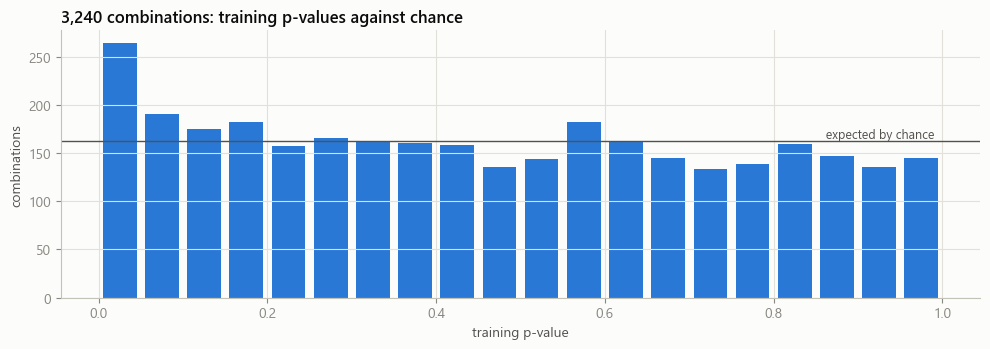

In [8]:
# Cell 18
fig, ax = plt.subplots(figsize=(10, 3.6))
counts, edges = np.histogram(SEARCH['p_train'], bins=20, range=(0, 1))
ax.bar(edges[:-1] + 0.025, counts, width=0.04, color=BLUE)
ax.axhline(M / 20, color=INK_2, lw=1)
ax.text(0.99, M / 20, '  expected by chance', va='bottom', ha='right', color=INK_2, fontsize=9)
ax.set_xlabel('training p-value')
ax.set_ylabel('combinations')
ax.set_title('3,240 combinations: training p-values against chance')
plt.tight_layout()
plt.savefig('../figures/search_pvalues.png', dpi=150)
plt.show()

**Cell 19**

**Goal.** Compare the distribution of p-values against what chance produces.

**Method.** Histogram the 3,240 training p-values in 20 bins, with a line at 162 per bin, the count a bin holds when every relationship is absent.

**Outcome.** The lowest bins stand above the line and the rest sit near it.

**Interpretation.** The excess in the low bins is the signal in the set, and its size of about 100 combinations matches the arithmetic in Cell 16. A histogram flat across all 20 bins would have closed the search here.

**Cell 20**

Share of combinations holding in test, by training p-value:

In [9]:
# Cell 21
SEARCH['training_strength'] = pd.cut(SEARCH['p_train'], [0, 0.001, 0.01, 0.05, 0.2, 1.0],
                                     labels=['p below 0.001', '0.001 to 0.01', '0.01 to 0.05', '0.05 to 0.2', 'above 0.2'])
CARRY = SEARCH.groupby('training_strength', observed=True)['holds_in_test'].agg(['mean', 'size']).rename(columns={'mean': 'share_holding_in_test', 'size': 'combinations'})
CARRY

,share_holding_in_test,combinations
training_strength,,
p below 0.001,0.160000,25
0.001 to 0.01,0.300000,60
0.01 to 0.05,0.340782,179
0.05 to 0.2,0.327239,547
above 0.2,0.420749,2429


**Cell 22**

**Goal.** Test whether a smaller training p-value holds more often out of sample.

**Method.** Bin the combinations by training p-value and take the share of each bin holding in test, where holding means the same sign and a lower error.

**Outcome.** p below 0.001: 16 percent of 25 combinations hold. 0.001 to 0.01: 30 percent of 60. 0.01 to 0.05: 34 percent of 179. 0.05 to 0.2: 33 percent of 547. Above 0.2: 42 percent of 2,429.

**Interpretation.** The order runs backwards: the smallest training p-values hold the least. A p-value below 0.001 on four years of weekly data marks a fit to the particular path those four years took, and 84 percent of those fits break in the next year. This is the reason the project drops the open search and takes its drivers from physical reasoning in Cell 33.

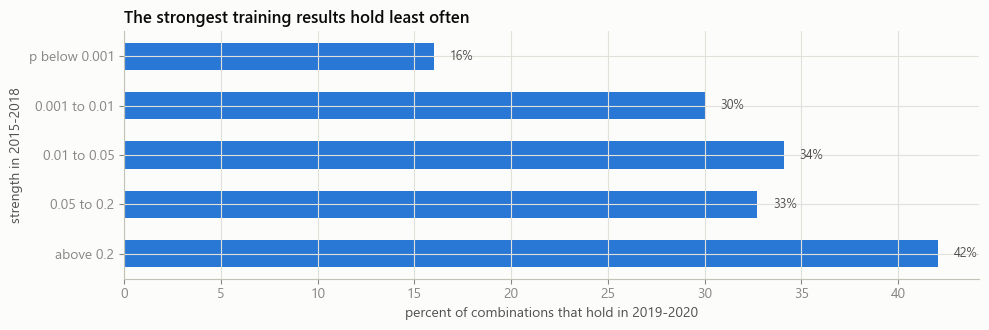

In [10]:
# Cell 23
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.barh(range(len(CARRY)), CARRY['share_holding_in_test'] * 100, height=0.55, color=BLUE)
ax.set_yticks(range(len(CARRY)))
ax.set_yticklabels(CARRY.index)
ax.invert_yaxis()
for i, v in enumerate(CARRY['share_holding_in_test'] * 100):
    ax.text(v + 0.8, i, f'{v:.0f}%', va='center', color=INK_2, fontsize=9)
ax.set_xlabel('percent of combinations that hold in 2019-2020')
ax.set_ylabel('strength in 2015-2018')
ax.set_title('The strongest training results hold least often')
plt.tight_layout()
plt.savefig('../figures/search_carryover.png', dpi=150)
plt.show()

**Cell 24**

**Goal.** Show the backwards order as one picture.

**Method.** Horizontal bars of the hold rate by training strength.

**Outcome.** The bar for p below 0.001 is the shortest at 16 percent, and the bar for p above 0.2 is the longest at 42 percent.

**Interpretation.** The chart is the argument against data mining in one image, and the fixed driver choice in Cell 33 comes from it.

In [11]:
# Cell 25
SEARCH[SEARCH['fdr_pass']].sort_values('p_train')[['spread', 'physical_number', 'h', 'b_train', 'p_train', 'b_test', 'test_error_gain', 'holds_in_test']].round(4)

,spread,physical_number,h,b_train,p_train,b_test,test_error_gain,holds_in_test
2462,LA_DIFF_1,P3_RUNS_VS_5Y,4,0.7391,0.0000,-0.4876,-0.0073,False
2426,LA_DIFF_1,P3_RUNS_VS_5Y,2,0.5591,0.0000,-0.4732,-0.0971,False
2420,LA_DIFF_1,P5_DAYS_SUPPLY,2,0.8592,0.0000,-0.2352,-0.1859,False
2384,LA_DIFF_1,P5_DAYS_SUPPLY,1,0.4806,0.0000,-0.3194,-0.1650,False
44,LA_GC_1,P5_DAYS_SUPPLY,2,0.6907,0.0000,0.6377,-0.0222,False
2421,LA_DIFF_1,P5_DAYS_SUPPLY_CHG4,2,0.5929,0.0001,-0.0559,-0.1438,False
2678,NY_DIFF_1,P3_RUNS_VS_5Y,4,0.4050,0.0001,-1.7984,-0.0005,False
100,LA_GC_1,P1_IMPORTS_4W,4,0.9728,0.0001,-0.1449,-0.1003,False
666,GC_JET_M1M2,P5_OUTPUT_VS_52W,1,0.1620,0.0001,0.0729,-0.0886,False
739,GC_JET_M1M2,P5_OUTPUT_VS_52W_CHG4,4,0.3187,0.0001,0.6748,0.0836,True


**Cell 26**

**Goal.** Read the 16 survivors one at a time.

**Method.** List the combinations passing the cutoff, sorted by training p-value, with the training and test coefficients and the test error gain.

**Outcome.** Thirteen of the 16 fail in test. LA_DIFF_1 with PADD 3 runs: b 0.739 in training, -0.488 in test. LA_DIFF_1 with PADD 5 days of supply: 0.859 to -0.235. LA_GC_1 with PADD 5 days of supply keeps its sign, 0.691 to 0.638, and the test error still rises. The three that hold pair GC_JET_M1M2 and gasoil M1-M2 with PADD 5 output measured against the prior 52 weeks, at h = 4.

**Interpretation.** A coefficient moving from +0.74 to -0.49 is the signature of a fit to one period. LA_DIFF_1 fills six of the 16 rows, and notebook 01 had already read the diffs as jet against heating oil instead of a clean regional bet, so the rows with the smallest p-values belong to the series with the least clean interpretation.

**Cell 27**

**Outcome.** Training p < 0.05: 264 combinations against 162 expected by chance. FDR cutoff at 0.00042: 16 pass. Confirmed in test: 3, all pairing PADD 5 jet output against the prior 52 weeks with the Gulf Coast jet and gasoil M1-M2 spreads at h = 4. Hold rate in test: 16 percent at training p < 0.001, 42 percent at p > 0.2. The confirmed share, 3 of 16 at 19 percent, sits below the hold rate of the weakest bin.

**Interpretation.** The open search fails its own test. A combination selected for training strength holds less often than one picked at random from the bin above p = 0.2, so the selection is running on noise. Every fair value from Cell 33 onward uses drivers fixed from physical reasoning, and the three confirmed rows stay out of the trading rule, since 3 of 3,240 is the count chance produces at this cutoff.

**Cell 28**

## 3. Pull back to the 26-week mean

Score: out-of-sample R² against the flat forecast (zero change), test period.

In [12]:
# Cell 29
OWN = []
for tgt in TARGETS:
    s = PANEL[tgt]
    own_gap = s - s.rolling(26).mean()
    for h in [1, 4]:
        y = s.shift(-(1 + h)) - s.shift(-1)
        df = pd.DataFrame({'y': y, 'c': own_gap})
        tr = df.loc[TRAIN[0]:TRAIN[1]].dropna()
        te = df.loc[TEST[0]:TEST[1]].dropna()
        fit = sm.OLS(tr['y'], sm.add_constant(tr[['c']])).fit()
        pred = fit.params['const'] + fit.params['c'] * te['c']
        r2 = 1 - ((te['y'] - pred) ** 2).sum() / (te['y'] ** 2).sum()
        hit = (np.sign(pred) == np.sign(te['y']))[te['y'] != 0].mean()
        OWN.append([tgt, h, round(fit.params['c'], 3), round(r2, 3), round(hit, 2)])
OWN = pd.DataFrame(OWN, columns=['spread', 'h', 'pull_back_coefficient', 'oos_r2_vs_no_change', 'direction_right'])
OWN[OWN['h'] == 4].sort_values('oos_r2_vs_no_change', ascending=False).head(12)

,spread,h,pull_back_coefficient,oos_r2_vs_no_change,direction_right
33,GASOIL_M1M2,4,-0.407,0.172,0.66
21,HO_M1M2,4,-0.270,0.128,0.66
5,NWE_GC_1,4,-0.319,0.121,0.66
1,LA_GC_1,4,-0.456,0.114,0.67
17,NY_JET_M1M2,4,-0.310,0.080,0.56
3,NY_GC_1,4,-0.204,0.074,0.62
53,HO_BRENT,4,-0.127,0.061,0.59
7,SING_GC_1,4,-0.303,0.060,0.54
35,GASOIL_M2M3,4,-0.433,0.042,0.61
23,HO_M2M3,4,-0.132,0.021,0.52


**Cell 30**

**Goal.** Measure how much of a spread's move its own distance from its 26-week average predicts.

**Method.** Regress the change from t+1 to t+1+h on the gap to the 26-week mean, fit on training weeks, then score on test weeks with out-of-sample R squared, which compares the squared forecast error against the error from forecasting zero change. Also report the share of weeks whose direction the forecast called.

**Outcome.** h = 4: GASOIL_M1M2 0.172, HO_M1M2 0.128, NWE_GC_1 0.121, LA_GC_1 0.114, NY_JET_M1M2 0.080, NY_GC_1 0.074, HO_BRENT 0.061, SING_GC_1 0.060. Direction called in 52 to 67 percent of weeks. Every pull-back coefficient is negative, -0.026 to -0.747.

**Interpretation.** A negative coefficient on the gap is reversion measured out of sample: a spread above its own average falls. R squared of 0.11 to 0.17 over four weeks is the size a spread trade works with, and it beats the flat forecast from the spread's own history alone. Section 4 asks whether physical numbers improve on that.

**Cell 31**

**Outcome.** At h = 4: GASOIL_M1M2 R squared 0.172; HO_M1M2 0.128, NWE_GC_1 0.121 and LA_GC_1 0.114; direction called in 66 to 67 percent of weeks. Every pull-back coefficient is negative.

**Interpretation.** Reversion to a 26-week average is measurable out of sample on the spreads notebook 01 selected, and it uses the spread alone. That 0.11 to 0.17 is the benchmark the fair-value model has to beat in section 4, and the reason the trading rule reads a distance instead of a direction.

**Cell 32**

## 4. Fair value, re-fitted each week

Each week t from 2017-01-06:
1. Fit spread on fixed drivers, weeks ≤ t. Fair value = fitted value; gap = spread - fair value.
2. Fit forecasts on weeks with known outcomes: own pull back, gap, both.
3. Forecast the change from t+1 to t+1+h.

In [13]:
# Cell 33
FV_DRIVERS = {
    'LA_GC_1':     ['P5_DAYS_SUPPLY', 'P5_RUNS_VS_5Y', 'P3_JET_STOCKS_VS_5Y'],   # PADD 5 supply, PADD 3 stocks
    'LA_JET_M1M2': ['P5_DAYS_SUPPLY', 'P5_RUNS_VS_5Y'],                          # PADD 5 supply
    'LA_JET_M2M3': ['P5_DAYS_SUPPLY', 'P5_RUNS_VS_5Y'],
    'SING_GC_1':   ['P3_JET_STOCKS_VS_5Y', 'P3_RUNS_VS_5Y'],                     # PADD 3 supply
    'NWE_GC_1':    ['P3_JET_STOCKS_VS_5Y', 'P3_RUNS_VS_5Y'],                     # PADD 3 supply
    'NY_GC_1':     ['P1_JET_STOCKS_VS_5Y', 'P3_JET_STOCKS_VS_5Y'],               # PADD 1 and PADD 3 stocks
    'GC_JET_M1M2': ['P3_JET_STOCKS_VS_5Y', 'P3_RUNS_VS_5Y'],                     # PADD 3 supply
    'HO_BRENT':    ['US_DIST_STOCKS_VS_5Y', 'US_UTIL_VS_5Y'],                    # distillate stocks, utilization
}
WEEKS = PANEL.loc[WF_START:WF_END].index
print(len(WEEKS), 'forecast weeks from', WEEKS[0].date(), 'to', WEEKS[-1].date())

177 forecast weeks from 2017-01-06 to 2020-05-22


**Cell 34**

**Goal.** Choose the fair-value drivers for eight spreads from physical reasoning.

**Method.** Two or three drivers per spread, each one the balance of the region that spread prices: West Coast supply for the three LA spreads, Gulf Coast supply for SING_GC_1, NWE_GC_1 and GC_JET_M1M2, East and Gulf Coast stocks for NY_GC_1, distillate stocks and refinery utilization for HO_BRENT. The set is fixed here and holds for every week of the walk-forward.

**Outcome.** 177 forecast weeks, 2017-01-06 to 2020-05-22.

**Interpretation.** Cell 25 showed what a search over 36 drivers returns, so these eight driver sets come from the physics of each region: the West Coast makes its own jet, the Gulf Coast exports it, the East Coast receives it. Fixing the set means each week's fit estimates coefficients on past data with the choice of columns settled in advance, which is the difference between a walk-forward and a search.

In [14]:
# Cell 35
t0 = time.time()
WF = []
for tgt, drv in FV_DRIVERS.items():
    s = PANEL[tgt]
    D = PANEL[[d + '_KNOWN' for d in drv]]
    own_gap = s - s.rolling(26).mean()
    for h in [1, 4]:
        y = s.shift(-(1 + h)) - s.shift(-1)
        for t in WEEKS:
            hist = pd.concat([s, D], axis=1).loc['2015-01-09':t].dropna()
            fv_fit = sm.OLS(hist.iloc[:, 0], sm.add_constant(hist.iloc[:, 1:])).fit()
            gap_hist = hist.iloc[:, 0] - fv_fit.predict(sm.add_constant(hist.iloc[:, 1:]))
            fair_value_now = float(fv_fit.predict(sm.add_constant(D.loc[[t]], has_constant='add')).iloc[0])
            gap_now = s.loc[t] - fair_value_now
            known_until = t - pd.Timedelta(weeks=1 + h)            # last known outcome
            F = pd.DataFrame({'y': y, 'own': own_gap, 'gap': gap_hist}).loc['2015-01-09':known_until].dropna()
            now = {'own': own_gap.loc[t], 'gap': gap_now}
            forecasts = []
            for cols in [['own'], ['gap'], ['own', 'gap']]:
                fit = sm.OLS(F['y'], sm.add_constant(F[cols])).fit()
                forecasts.append(fit.params['const'] + sum(fit.params[c] * now[c] for c in cols))
            WF.append([tgt, h, t, s.loc[t], fair_value_now, gap_now] + forecasts + [y.loc[t]])
WF = pd.DataFrame(WF, columns=['spread', 'h', 'week', 'spread_level', 'fair_value', 'gap', 'f_own', 'f_fair_value', 'f_both', 'actual'])
print(len(WF), 'forecasts in', round(time.time() - t0), 'seconds')

2832 forecasts in 45 seconds


**Cell 36**

**Goal.** Produce a forecast for each week using the data available in that week.

**Method.** For each spread, horizon and week t: fit the spread on its drivers over 2015 to t, take the fitted value as fair value and the residual as the gap. Then fit three forecasting models on the weeks whose outcome was already public at t, using the own gap, the fair-value gap, and both, and apply each to week t. The cutoff for that fit sample is t minus 1+h weeks, so an outcome still running stays out of it.

**Outcome.** 2,832 forecasts in 45 seconds.

**Interpretation.** Everything a forecast uses existed in its own week: the coefficients, the fair value and the driver values. The 1+h shift on the fit sample is the detail that keeps the outcome a forecast predicts out of the data that produced the forecast.

In [15]:
# Cell 37
# pre-COVID outcomes
WF['outcome_end'] = WF['week'] + pd.to_timedelta(7 * (1 + WF['h']), unit='D')
PRE = WF[WF['outcome_end'] <= PRE_COVID_END]
FV_SCORE = []
for (tgt, h), g in PRE.groupby(['spread', 'h'], sort=False):
    row = [tgt, h, len(g)]
    for f in ['f_own', 'f_fair_value', 'f_both']:
        row.append(round(1 - ((g['actual'] - g[f]) ** 2).sum() / (g['actual'] ** 2).sum(), 3))
        row.append(round((np.sign(g[f]) == np.sign(g['actual']))[g['actual'] != 0].mean(), 2))
    FV_SCORE.append(row)
FV_SCORE = pd.DataFrame(FV_SCORE, columns=['spread', 'h', 'weeks', 'r2_own', 'hit_own', 'r2_fair_value', 'hit_fair_value', 'r2_both', 'hit_both'])
FV_SCORE

,spread,h,weeks,r2_own,hit_own,r2_fair_value,hit_fair_value,r2_both,hit_both
0,LA_GC_1,1,163,0.010,0.56,0.009,0.60,0.013,0.60
1,LA_GC_1,4,160,0.126,0.64,0.179,0.68,0.172,0.70
2,LA_JET_M1M2,1,163,0.092,0.65,0.070,0.64,0.085,0.64
3,LA_JET_M1M2,4,160,0.140,0.65,0.112,0.63,0.135,0.65
4,LA_JET_M2M3,1,163,0.071,0.56,0.071,0.60,0.061,0.60
5,LA_JET_M2M3,4,160,0.113,0.56,0.115,0.64,0.096,0.62
6,SING_GC_1,1,163,0.037,0.55,0.023,0.54,0.032,0.58
7,SING_GC_1,4,160,0.052,0.57,0.064,0.54,0.050,0.54
8,NWE_GC_1,1,163,0.019,0.55,0.036,0.60,0.030,0.59
9,NWE_GC_1,4,160,0.078,0.57,0.132,0.62,0.121,0.66


**Cell 38**

**Goal.** Score the three models on out-of-sample weeks that end before the 2020 collapse.

**Method.** Keep the forecasts whose outcome window ends on or before 2020-02-28, then take out-of-sample R squared and the direction share for each spread, horizon and model.

**Outcome.** h = 4, fair value against own mean: LA_GC_1 0.179 / 0.126, NWE_GC_1 0.132 / 0.078, NY_GC_1 0.096 / 0.043, SING_GC_1 0.064 / 0.052, LA_JET_M2M3 0.115 / 0.113. Own mean higher: LA_JET_M1M2 0.112 / 0.140, GC_JET_M1M2 0.014 / 0.092. Direction 51 to 70 percent. At h = 1 every R squared sits between -0.024 and 0.092.

**Interpretation.** Physical drivers add to the pull-back model for the four spreads that price one region against another, where a fair value can stand apart from a moving average, and they subtract for the two Gulf Coast time spreads. LA_GC_1 gains 5.3 points of R squared, from 12.6 to 17.9 percent, and that gain is the central result of the project. One-week forecasts sit near zero for every spread, which sets the horizon at four weeks.

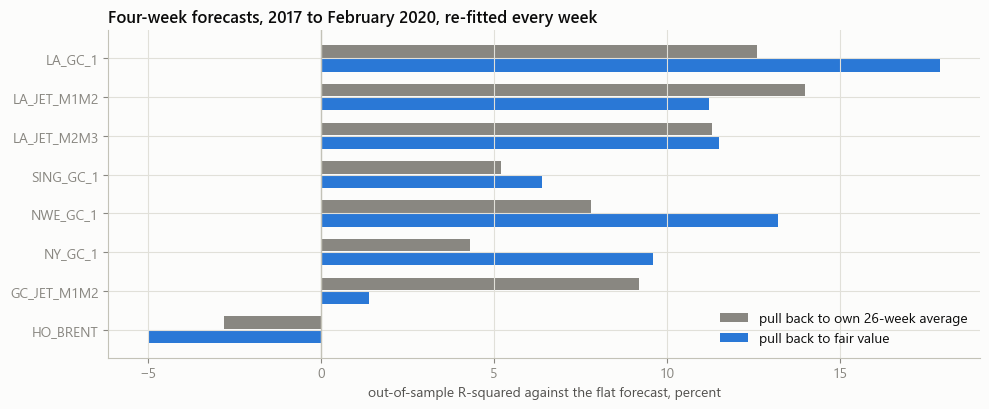

In [16]:
# Cell 39
S4 = FV_SCORE[FV_SCORE['h'] == 4].set_index('spread')
fig, ax = plt.subplots(figsize=(10, 4.2))
pos = np.arange(len(S4))
ax.barh(pos - 0.18, S4['r2_own'] * 100, height=0.32, color=MUTED, label='pull back to own 26-week average')
ax.barh(pos + 0.18, S4['r2_fair_value'] * 100, height=0.32, color=BLUE, label='pull back to fair value')
ax.set_yticks(pos)
ax.set_yticklabels(S4.index)
ax.invert_yaxis()
ax.axvline(0, color=AXIS, lw=1)
ax.set_xlabel('out-of-sample R-squared against the flat forecast, percent')
ax.set_title('Four-week forecasts, 2017 to February 2020, re-fitted every week')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../figures/fair_value_vs_own_average.png', dpi=150)
plt.show()

**Cell 40**

**Goal.** Compare the two models across the eight spreads in one picture.

**Method.** Paired horizontal bars of out-of-sample R squared for the own-average model and the fair-value model, h = 4.

**Outcome.** Fair value stands higher for five spreads and lower for three.

**Interpretation.** The picture puts each spread against the choice it presents: the spreads across regions answer to regional balances, and the Gulf Coast time spreads answer to their own history.

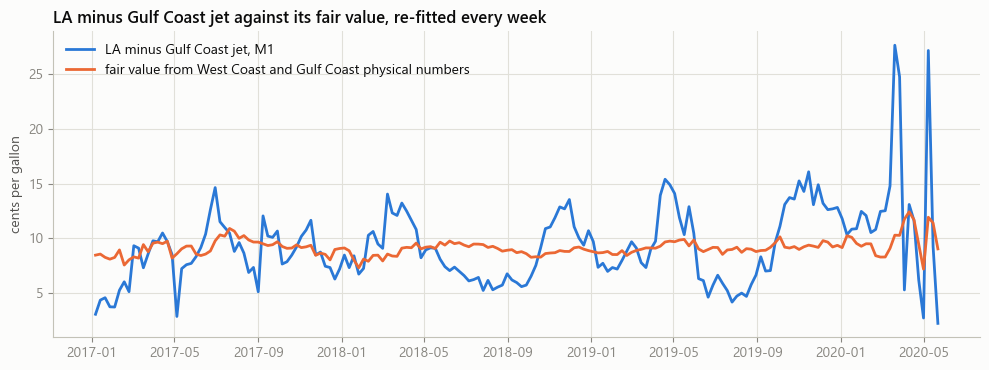

In [17]:
# Cell 41
# LA_GC_1 against fair value
G = WF[(WF['spread'] == 'LA_GC_1') & (WF['h'] == 4)].set_index('week')
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(G.index, G['spread_level'], color=BLUE, label='LA minus Gulf Coast jet, M1')
ax.plot(G.index, G['fair_value'], color=ORANGE, label='fair value from West Coast and Gulf Coast physical numbers')
ax.set_ylabel('cents per gallon')
ax.set_title('LA minus Gulf Coast jet against its fair value, re-fitted every week')
ax.legend(loc='upper left')
plt.tight_layout()
plt.savefig('../figures/la_gc_fair_value.png', dpi=150)
plt.show()

**Cell 42**

**Goal.** Show the West Coast spread against its fair value, week by week.

**Method.** Plot the spread level and the weekly re-fitted fair value from 2017.

**Outcome.** Fair value runs 8 to 12 c/gal before COVID while the spread runs 3 to 16, crossing the fair-value line many times.

**Interpretation.** The trade is the distance between the two lines: the spread stands 4 c/gal above a fair value of 9, then returns to it. The fair-value line moves 4 c/gal across three years because it tracks stock and refinery levels, so a gap opening is a movement of the spread against a reference that holds.

**Cell 43**

**Outcome.** R squared at h = 4, fair value against own mean: LA_GC_1 17.9 / 12.6; NWE_GC_1 13.2 / 7.8; NY_GC_1 9.6 / 4.3; SING_GC_1 6.4 / 5.2; LA_JET_M2M3 11.5 / 11.3. Own mean higher: LA_JET_M1M2, GC_JET_M1M2. HO_BRENT: both models below zero. Direction 54 to 68 percent. LA_GC_1 before COVID: fair value 8 to 12 c/gal against a spread of 3 to 16.

**Interpretation.** Physical balances improve the forecast for every spread that prices one region against another, and they fail for the two Gulf Coast time spreads and for the distillate crack. The improvement runs 1 to 5 points of R squared, which is small in absolute terms and large against the 12.6 it starts from. HO_BRENT scoring below zero in both models, after holding the largest correlation in notebook 02 at -0.68, is the clearest case in the project of a correlation that fails as a forecast.

**Cell 44**

## 5. Trading rule

Position +1 / -1 by the sign of the 4-week forecast; entry at next week's mean price; one-week hold; cost 0.25 c/gal per unit traded. 1,000 bbl: 420 dollars per cent. Headline model: fair value.

In [18]:
# Cell 45
BT = []
WEEKLY = {}
W4 = WF[WF['h'] == 4].copy()
for tgt, g in W4.groupby('spread', sort=False):
    g = g.set_index('week')
    s = PANEL[tgt]
    next_week_move = (s.shift(-2) - s.shift(-1)).reindex(g.index)
    for f in ['f_own', 'f_fair_value', 'f_both']:
        position = np.sign(g[f])
        net = position * next_week_move - COST * position.diff().abs().fillna(1)
        WEEKLY[(tgt, f)] = net
        for period, part in [('2017 to Feb 2020', net.loc[:PRE_COVID_END - pd.Timedelta(weeks=2)]), ('COVID, Mar to May 2020', net.loc[PRE_COVID_END - pd.Timedelta(weeks=1):])]:
            part = part.dropna()
            sharpe = part.mean() / part.std() * np.sqrt(52) if part.std() > 0 else np.nan
            BT.append([tgt, f, period, len(part), round(part.sum(), 1), round(part.mean() * 52, 1), round(sharpe, 2),
                       round((part > 0).mean(), 2), round((part.cumsum() - part.cumsum().cummax()).min(), 1)])
BT = pd.DataFrame(BT, columns=['spread', 'model', 'period', 'weeks', 'total_cents', 'cents_per_year', 'sharpe', 'weeks_won', 'worst_drawdown'])
BT[BT['period'] == '2017 to Feb 2020'].pivot_table(index='spread', columns='model', values='sharpe', sort=False)

model,f_own,f_fair_value,f_both
spread,,,
LA_GC_1,0.80,0.81,1.24
LA_JET_M1M2,1.24,1.18,1.10
LA_JET_M2M3,0.73,1.00,0.71
SING_GC_1,0.82,0.06,0.52
NWE_GC_1,0.14,0.36,0.57
NY_GC_1,-0.06,0.73,0.58
GC_JET_M1M2,-0.13,-0.21,-0.07
HO_BRENT,-0.25,-0.05,0.12


**Cell 46**

**Goal.** Turn each forecast into a position and measure the profit after cost.

**Method.** Position +1 or -1 by the sign of the 4-week forecast, entered at next week's mean price and held one week. Cost 0.25 c/gal each time the position changes. Sharpe ratio = mean weekly profit / standard deviation of weekly profit x the square root of 52, which states profit per unit of the swing around it, per year.

**Outcome.** Pre-COVID Sharpe under the fair-value model: LA_JET_M1M2 1.18, LA_JET_M2M3 1.00, LA_GC_1 0.81, NY_GC_1 0.73, NWE_GC_1 0.36, SING_GC_1 0.06, HO_BRENT -0.05, GC_JET_M1M2 -0.21. The both-driver model lifts LA_GC_1 to 1.24.

**Interpretation.** The R squared ordering carries into money for the West Coast spreads and breaks for SING_GC_1, where 6.4 percent R squared pays a Sharpe of 0.06. A forecast can hold information and still lose to cost, so this table is the test that decides the book.

In [19]:
# Cell 47
BT[(BT['period'] == '2017 to Feb 2020') & (BT['model'] == 'f_fair_value')]

,spread,model,period,weeks,total_cents,cents_per_year,sharpe,weeks_won,worst_drawdown
2,LA_GC_1,f_fair_value,2017 to Feb 2020,163,29.5,9.4,0.81,0.56,-15.6
8,LA_JET_M1M2,f_fair_value,2017 to Feb 2020,163,38.4,12.2,1.18,0.60,-6.5
14,LA_JET_M2M3,f_fair_value,2017 to Feb 2020,163,22.3,7.1,1.00,0.50,-6.1
20,SING_GC_1,f_fair_value,2017 to Feb 2020,163,1.9,0.6,0.06,0.52,-14.0
26,NWE_GC_1,f_fair_value,2017 to Feb 2020,163,10.7,3.4,0.36,0.53,-12.7
32,NY_GC_1,f_fair_value,2017 to Feb 2020,163,11.8,3.8,0.73,0.57,-3.0
38,GC_JET_M1M2,f_fair_value,2017 to Feb 2020,163,-3.8,-1.2,-0.21,0.50,-10.4
44,HO_BRENT,f_fair_value,2017 to Feb 2020,163,-2.5,-0.8,-0.05,0.51,-26.6


**Cell 48**

**Goal.** Read the profit, the win rate and the worst drawdown for each spread.

**Method.** Print the fair-value rows of the backtest table for 2017 to February 2020.

**Outcome.** 163 weeks each. LA_JET_M1M2 38.4 c/gal total, 12.2 a year, drawdown -6.5. LA_GC_1 29.5, 9.4, -15.6. LA_JET_M2M3 22.3, 7.1, -6.1. NY_GC_1 11.8, 3.8, -3.0. NWE_GC_1 10.7, 3.4, -12.7. SING_GC_1 1.9, 0.6, -14.0. GC_JET_M1M2 -3.8. HO_BRENT -2.5, drawdown -26.6. Win rates 0.50 to 0.60.

**Interpretation.** A win rate near 0.55 with a positive total says the rule wins a little more often than it loses and keeps its winners the same size as its losers. Drawdown separates the spreads over a wider range than the annual profit does: SING_GC_1 earns 0.6 a year against a 14.0 loss along the way, which is a position to drop.

In [20]:
# Cell 49
# shortlist book
BOOK = pd.concat([WEEKLY[(tgt, 'f_fair_value')] for tgt in SHORTLIST], axis=1, keys=SHORTLIST)
BOOK_PRE = BOOK.loc[:PRE_COVID_END - pd.Timedelta(weeks=2)].dropna()
BOOK_PRE['book'] = BOOK_PRE[SHORTLIST].sum(axis=1)
book = BOOK_PRE['book']
print('weeks:', len(book))
print('total, cents per gallon:', round(book.sum(), 1), '| per year:', round(book.mean() * 52, 1))
print('Sharpe ratio:', round(book.mean() / book.std() * np.sqrt(52), 2), '| weeks won:', round((book > 0).mean(), 2))
print('worst drawdown:', round((book.cumsum() - book.cumsum().cummax()).min(), 1))
print('correlation between the four weekly profit streams:')
print(BOOK_PRE[SHORTLIST].corr().round(2))

weeks: 163
total, cents per gallon: 51.3 | per year: 16.4
Sharpe ratio: 0.63 | weeks won: 0.55
worst drawdown: -38.3
correlation between the four weekly profit streams:
             LA_GC_1  LA_JET_M2M3  SING_GC_1  HO_BRENT
LA_GC_1         1.00        -0.00       0.21      0.01
LA_JET_M2M3    -0.00         1.00       0.28      0.09
SING_GC_1       0.21         0.28       1.00      0.08
HO_BRENT        0.01         0.09       0.08      1.00


**Cell 50**

**Goal.** Measure the four spreads notebook 01 shortlisted as one book.

**Method.** Sum the weekly profit of the four fair-value positions, one unit each, then take the total, the Sharpe, the win rate, the drawdown and the correlation between the four profit streams.

**Outcome.** 163 weeks, 51.3 c/gal total, 16.4 a year, Sharpe 0.63, 55 percent of weeks positive, worst drawdown -38.3. Profit correlations: SING_GC_1 with LA_JET_M2M3 0.28, SING_GC_1 with LA_GC_1 0.21, and every other pair at 0.09 or below.

**Interpretation.** Correlations at or below 0.28 mean these are four separate bets, which is what the clustering rule in notebook 01 selected them for. The book's 0.63 sits below LA_JET_M1M2 alone at 1.18, because two of the four earn under 1 c/gal a year and dilute the two that work.

In [21]:
# Cell 51
# West Coast book (PLAN.md)
WEST = ['LA_GC_1', 'LA_JET_M1M2', 'LA_JET_M2M3']
WEST_BOOK = pd.concat([WEEKLY[(tgt, 'f_fair_value')] for tgt in WEST], axis=1, keys=WEST)
WEST_PRE = WEST_BOOK.loc[:PRE_COVID_END - pd.Timedelta(weeks=2)].dropna().sum(axis=1)
WEST_COVID = WEST_BOOK.loc[PRE_COVID_END - pd.Timedelta(weeks=1):].dropna().sum(axis=1)
for label, w in [('2017 to Feb 2020', WEST_PRE), ('COVID, Mar to May 2020', WEST_COVID)]:
    print(label, '| weeks', len(w), '| total', round(w.sum(), 1), '| per year', round(w.mean() * 52, 1),
          '| Sharpe', round(w.mean() / w.std() * np.sqrt(52), 2), '| weeks won', round((w > 0).mean(), 2),
          '| worst drawdown', round((w.cumsum() - w.cumsum().cummax()).min(), 1))

2017 to Feb 2020 | weeks 163 | total 90.2 | per year 28.8 | Sharpe 1.5 | weeks won 0.56 | worst drawdown -14.0
COVID, Mar to May 2020 | weeks 14 | total 103.1 | per year 383.1 | Sharpe 2.3 | weeks won 0.57 | worst drawdown -22.4


**Cell 52**

**Goal.** Measure the three West Coast spreads as one book, before the collapse and through it.

**Method.** Sum the three fair-value profit streams and report both periods.

**Outcome.** 2017 to February 2020: 163 weeks, 90.2 c/gal total, 28.8 a year, Sharpe 1.50, 56 percent of weeks positive, worst drawdown -14.0. March to May 2020: 14 weeks, 103.1 c/gal, Sharpe 2.30, worst drawdown -22.4.

**Interpretation.** The West Coast book earns 28.8 a year against the shortlist's 16.4 and holds its drawdown to 14.0 against 38.3, so concentration in one region beats spreading across four here. The 103.1 came from 14 weeks outside every training sample, and it is one episode instead of a repeatable result.

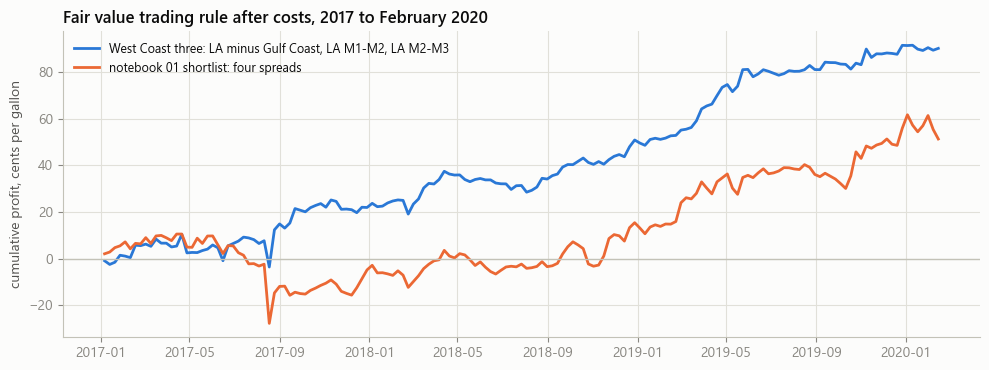

In [22]:
# Cell 53
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(WEST_PRE.index, WEST_PRE.cumsum(), color=BLUE, label='West Coast three: LA minus Gulf Coast, LA M1-M2, LA M2-M3')
ax.plot(book.index, book.cumsum(), color=ORANGE, label='notebook 01 shortlist: four spreads')
ax.axhline(0, color=AXIS, lw=1)
ax.set_ylabel('cumulative profit, cents per gallon')
ax.set_title('Fair value trading rule after costs, 2017 to February 2020')
ax.legend(loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/backtest_west_coast.png', dpi=150)
plt.show()

**Cell 54**

**Goal.** Compare the cumulative profit of the two books.

**Method.** Plot the running sum of each book's weekly profit, 2017 to February 2020.

**Outcome.** The West Coast line rises to about 90 c/gal with shallow setbacks; the shortlist line rises to about 51 with a deeper fall in the middle.

**Interpretation.** Both lines end above zero, and the West Coast line is the smoother of the two, which is the Sharpe difference of 1.50 against 0.63 in one picture.

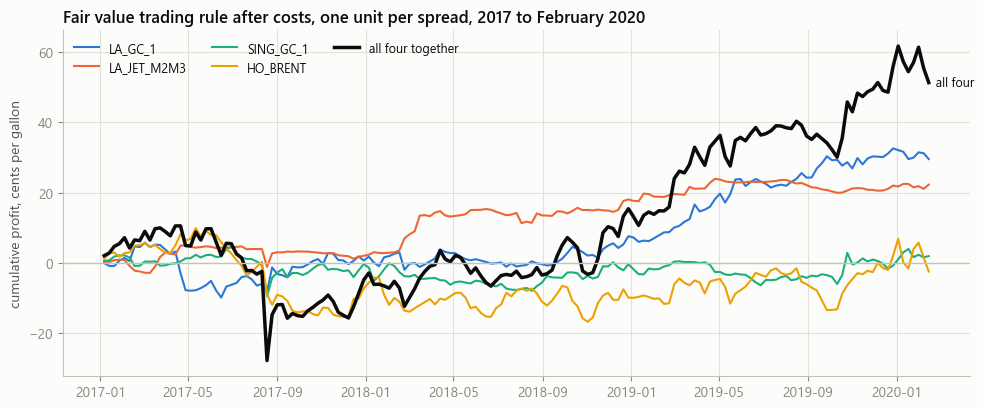

In [23]:
# Cell 55
fig, ax = plt.subplots(figsize=(10, 4.2))
CUM = BOOK_PRE.cumsum()
colours = {'LA_GC_1': BLUE, 'LA_JET_M2M3': ORANGE, 'SING_GC_1': AQUA, 'HO_BRENT': YELLOW}
for tgt in SHORTLIST:
    ax.plot(CUM.index, CUM[tgt], color=colours[tgt], lw=1.5, label=tgt)
ax.plot(CUM.index, CUM['book'], color=INK, lw=2.5, label='all four together')
ax.text(CUM.index[-1], CUM['book'].iloc[-1], '  all four', va='center', color=INK, fontsize=9)
ax.axhline(0, color=AXIS, lw=1)
ax.set_ylabel('cumulative profit, cents per gallon')
ax.set_title('Fair value trading rule after costs, one unit per spread, 2017 to February 2020')
ax.legend(loc='upper left', ncol=3, fontsize=9)
plt.tight_layout()
plt.savefig('../figures/backtest_book.png', dpi=150)
plt.show()

**Cell 56**

**Goal.** Show what each of the four shortlist spreads contributes.

**Method.** Plot the running profit of each spread and of the four together.

**Outcome.** LA_GC_1 and LA_JET_M2M3 rise through the period; SING_GC_1 and HO_BRENT end near zero after long swings either side of it.

**Interpretation.** The book's result belongs to the two LA spreads, and the two flat lines carry the drawdown. That split is the case for the West Coast book over the shortlist.

In [24]:
# Cell 57
# COVID weeks
BT[(BT['period'] == 'COVID, Mar to May 2020') & (BT['model'] == 'f_fair_value')]

,spread,model,period,weeks,total_cents,cents_per_year,sharpe,weeks_won,worst_drawdown
3,LA_GC_1,f_fair_value,"COVID, Mar to May 2020",14,12.5,46.5,0.58,0.43,-17.9
9,LA_JET_M1M2,f_fair_value,"COVID, Mar to May 2020",14,42.5,157.9,1.65,0.57,-26.4
15,LA_JET_M2M3,f_fair_value,"COVID, Mar to May 2020",14,48.1,178.6,2.70,0.71,-10.0
21,SING_GC_1,f_fair_value,"COVID, Mar to May 2020",14,17.5,65.1,2.07,0.71,-12.0
27,NWE_GC_1,f_fair_value,"COVID, Mar to May 2020",14,4.0,15.0,0.44,0.57,-14.1
33,NY_GC_1,f_fair_value,"COVID, Mar to May 2020",14,23.7,87.9,1.76,0.50,-18.3
39,GC_JET_M1M2,f_fair_value,"COVID, Mar to May 2020",14,-3.8,-14.0,-0.40,0.50,-13.1
45,HO_BRENT,f_fair_value,"COVID, Mar to May 2020",14,-12.9,-47.9,-1.23,0.43,-31.0


**Cell 58**

**Goal.** Read what each spread did through the demand collapse.

**Method.** Print the fair-value rows for March to May 2020, 14 weeks.

**Outcome.** LA_JET_M2M3 +48.1 c/gal, LA_JET_M1M2 +42.5, NY_GC_1 +23.7, SING_GC_1 +17.5, LA_GC_1 +12.5, NWE_GC_1 +4.0, GC_JET_M1M2 -3.8, HO_BRENT -12.9 with a drawdown of -31.0.

**Interpretation.** The time spreads paid most: a demand collapse pushes the nearer month below the later month, and a fair value fitted on stocks and refinery runs reads the stock build that drives it. HO_BRENT lost 12.9 in 14 weeks against 2.5 over the previous three years, which places the crack outside the range this model handles.

**Cell 59**

Sharpe = annual mean / annual standard deviation of weekly profit.

**Outcome.** Fair-value model, pre-COVID Sharpe: LA_GC_1 0.81, LA_JET_M1M2 1.18, LA_JET_M2M3 1.00, NY_GC_1 0.73; SING_GC_1 0.06, worth 0.6 c/gal a year; GC_JET_M1M2 -0.21; HO_BRENT -0.05.

| Book | Selection | Weeks | c/gal a year | Sharpe | Max drawdown |
|---|---|---|---|---|---|
| Shortlist: LA_GC_1, LA_JET_M2M3, SING_GC_1, HO_BRENT | notebook 01 | 163 | 16.4 | 0.63 | -38.3 |
| West Coast: LA_GC_1, LA_JET_M1M2, LA_JET_M2M3 | PLAN.md | 163 | 28.8 | 1.50 | -14.0 |

- Profit correlation inside each book: 0.28 or below.
- COVID, 14 weeks: West Coast +103 c/gal; HO_BRENT -12.9.
- West Coast book at 50,000 bbl per spread: 605,000 dollars a year.
- Fills: the weekly mean price. Daily prices would give the fill a trader received.
- Liquidity: bid-ask, depth and volume for regional jet swaps sit outside this dataset. Break-even cost per unit traded: West Coast three 0.74 c/gal (Sharpe 0.72 at a cost of 0.50, -0.69 at 1.00); shortlist 0.49 c/gal.

**Interpretation.** The West Coast book is the result: 28.8 c/gal a year at Sharpe 1.50, on 163 weeks outside every fit sample, with a drawdown of 14.0. Its break-even cost of 0.74 c/gal against the 0.25 assumed is the margin the whole result rests on, and it is the number to attack first: three times the assumed cost erases it. The liquidity of a regional jet swap decides whether 0.25 or 0.74 is the live number, and measuring it takes bid-ask and volume data from outside this dataset.

In [25]:
# Cell 60
SEARCH.to_csv('../results/signal_search.csv', index=False)
FV_SCORE.to_csv('../results/fair_value_scores.csv', index=False)
WF.to_csv('../results/fair_value_walkforward.csv', index=False)
BT.to_csv('../results/backtest.csv', index=False)
print('saved')

saved


**Cell 61**

**Goal.** Save the four result tables.

**Method.** Write `signal_search.csv`, `fair_value_scores.csv`, `fair_value_walkforward.csv` and `backtest.csv` to `results/`.

**Outcome.** Four files saved.

**Interpretation.** The dashboard reads `backtest.csv` and `fair_value_walkforward.csv`, and its in-page check recomputes the headline numbers from those two files.

**Cell 62**

## Summary

| Test | Result |
|---|---|
| Open search | 3 of 3,240 confirmed; hold rate falls as the training p-value falls |
| Pull back, h = 4 | R squared 0.11 to 0.17 |
| Fair value against own mean | higher for LA_GC_1, NWE_GC_1, NY_GC_1, SING_GC_1 |
| West Coast book | 28.8 c/gal a year, Sharpe 1.50, 2017 to 2020-02 |
| Shortlist book | Sharpe 0.63 |
| COVID | West Coast +103 c/gal; HO_BRENT -12.9 |

**Outcome.** A search over 3,240 combinations returned three results that hold, and eight fair values built from fixed physical drivers returned a West Coast book paying 28.8 c/gal a year at Sharpe 1.50 after cost.

**Interpretation.** The two halves of this notebook answer the same question in opposite directions. The search shows that selecting a driver on statistical strength produces results that break the next year. The fair values show that selecting a driver on physical reasoning, then fitting it forward one week at a time, produces a book that holds. The order matters: the physics chooses the columns and the data sets the coefficients.